In [13]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve
from astroML.utils import split_samples, completeness_contamination

In [14]:
data = pd.read_parquet('SGcolorSeparation.parquet')
# separate into stars and galaxies 
stars = data[data['starFlag'] == True]
gals = data[data['starFlag'] == False] 
qso = stars[stars['ug']<0.65] # "magic" UV color cut to select unresolved objects that are likely quasars
data


,detect_isIsolated,starFlag,rmag,ug,gr,ri,iz,zy
12376,True,False,23.745167,0.728010,1.844269,1.159029,0.921898,0.126497
12382,True,False,24.350838,1.088070,0.928684,0.445742,0.061237,0.267454
12402,True,True,24.499500,1.308189,0.665869,0.168119,0.041668,0.549952
12410,True,False,23.674450,0.156736,0.403383,0.457443,0.410912,0.135900
12430,True,False,23.510637,0.163691,0.870140,0.067169,0.012167,0.520754
...,...,...,...,...,...,...,...,...
865262,False,False,23.809626,0.277700,0.353355,0.568918,0.422571,0.349951
865263,False,False,23.893673,0.009878,0.180576,0.481710,0.457668,-0.008884
865265,False,False,24.503365,1.561340,0.303154,0.288425,0.046570,0.078903
865266,False,False,24.894373,0.591110,0.817085,0.170979,0.211695,-1.333220


In [15]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve
from astroML.utils import completeness_contamination
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# data things
features = ['ug', 'gr', 'ri', 'iz', 'zy']
tests = ['starFlag']

# Load data
data = pd.read_parquet('SGcolorSeparation.parquet')

# clean
for col in features:
    data = data[(data[col] > -5) & (data[col] < 5)]

data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=data.columns)

# get idx / split for test and train
train_idx, test_idx = train_test_split(data.index, train_size=0.8, 
                                       test_size=0.2, random_state=42)


X_train = data.loc[train_idx, features].values
X_test = data.loc[test_idx, features].values
y_train = data.loc[train_idx, tests].astype(int).values.ravel()
y_test = data.loc[test_idx, tests].astype(int).values.ravel()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

test_rmag = data.loc[test_idx, 'rmag'].values
mask_bright = test_rmag < 24
mask_faint = (test_rmag >= 24) & (test_rmag < 25)
mask_iso = data.loc[test_idx, 'detect_isIsolated'].astype(bool).values

# classify and stuff
classifiers = []
predictions = []
Ncolors = np.arange(1, X_train.shape[1] + 1)
kvals = [1, 100]

for k in kvals:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test.ravel())

print("completeness", completeness)
print("contamination", contamination)


# compute the decision boundary
clf = classifiers[-1][-1]
xlim = (X_test[:, 0].min() - 0.05, X_test[:, 0].max() + 0.05)
ylim = (X_test[:, 1].min() - 0.05, X_test[:, 1].max() + 0.05)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))

Z = clf.predict(np.c_[
    xx.ravel(), 
    yy.ravel(), 
    np.full_like(xx.ravel(), np.median(X_test[:, 2])), 
    np.full_like(xx.ravel(), np.median(X_test[:, 3])), 
    np.full_like(xx.ravel(), np.median(X_test[:, 4]))
])
Z = Z.reshape(xx.shape)

completeness [[0.2640869  0.41683639 0.53564155 0.58723693 0.5964019 ]
 [0.26205024 0.39273591 0.57162254 0.62355737 0.63408011]]
contamination [[0.73519401 0.59121172 0.46344781 0.43204202 0.42374549]
 [0.35289187 0.20371645 0.20938967 0.19500438 0.18249453]]


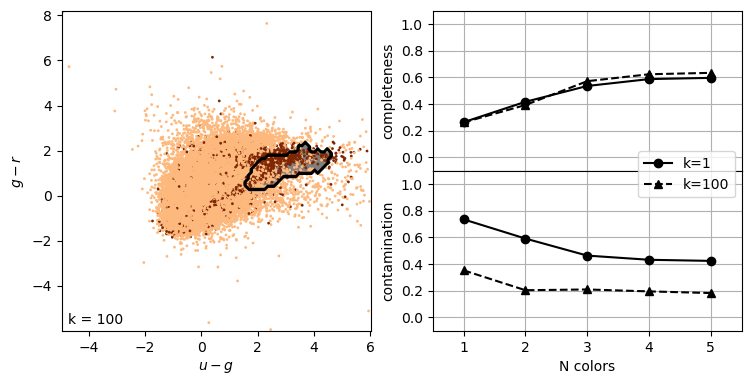

In [16]:
N_plot = len(X_test)

# plot the results
fig = plt.figure(figsize=(8, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X_test[-N_plot:, 0], X_test[-N_plot:, 1], c=y_test[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 2)

ax.contour(xx, yy, Z, [0.5], colors='k')
ax.contour(xx, yy, Z, [0.9], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

ax.text(0.02, 0.02, "k = %i" % kvals[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)

ax.plot(Ncolors, completeness[0], 'o-k', ms=6, label='k=%i' % kvals[0])
ax.plot(Ncolors, completeness[1], '^--k', ms=6, label='k=%i' % kvals[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], 'o-k', ms=6, label='k=%i' % kvals[0])
ax.plot(Ncolors, contamination[1], '^--k', ms=6, label='k=%i' % kvals[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))
ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

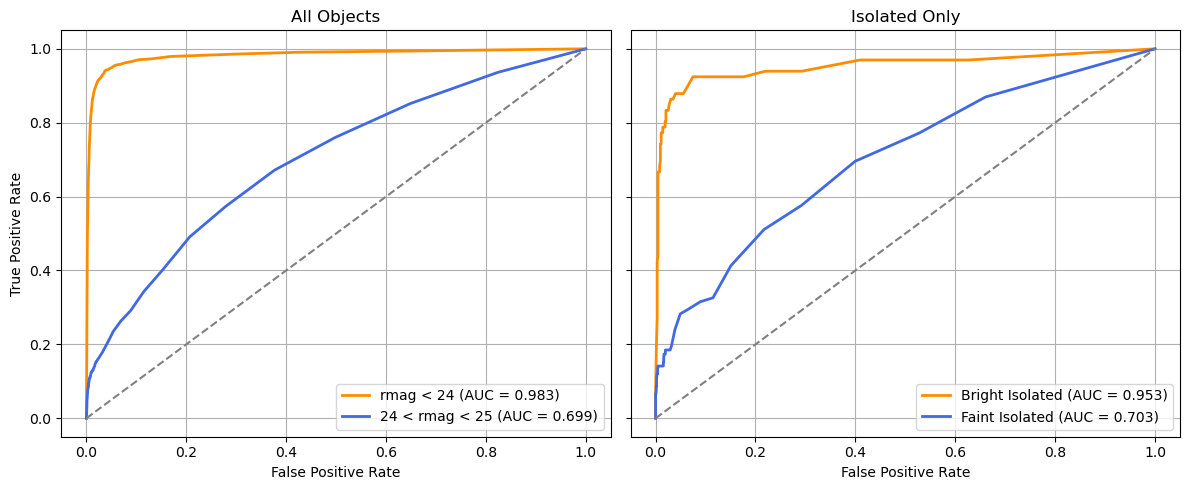

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
y_prob = clf.predict_proba(X_test)[:, 1]


fpr_b, tpr_b, _ = roc_curve(y_test[mask_bright], y_prob[mask_bright])
auc_b = auc(fpr_b, tpr_b)
ax1.plot(fpr_b, tpr_b, color='darkorange', lw=2, label=f'rmag < 24 (AUC = {auc_b:.3f})')

fpr_f, tpr_f, _ = roc_curve(y_test[mask_faint], y_prob[mask_faint])
auc_f = auc(fpr_f, tpr_f)
ax1.plot(fpr_f, tpr_f, color='royalblue', lw=2, label=f'24 < rmag < 25 (AUC = {auc_f:.3f})')

ax1.plot([0, 1], [0, 1], color='grey', linestyle='--')
ax1.set_title("All Objects")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc='lower right')
ax1.grid(True)


fpr_bi, tpr_bi, _ = roc_curve(y_test[mask_bright & mask_iso], y_prob[mask_bright & mask_iso])
auc_bi = auc(fpr_bi, tpr_bi)
ax2.plot(fpr_bi, tpr_bi, color='darkorange', lw=2, label=f'Bright Isolated (AUC = {auc_bi:.3f})')

fpr_fi, tpr_fi, _ = roc_curve(y_test[mask_faint & mask_iso], y_prob[mask_faint & mask_iso])
auc_fi = auc(fpr_fi, tpr_fi)
ax2.plot(fpr_fi, tpr_fi, color='royalblue', lw=2, label=f'Faint Isolated (AUC = {auc_fi:.3f})')

ax2.plot([0, 1], [0, 1], color='grey', linestyle='--')
ax2.set_title("Isolated Only")
ax2.set_xlabel("False Positive Rate")
ax2.legend(loc='lower right')
ax2.grid(True)

plt.tight_layout()
plt.show()


In [18]:
y_pred_binary = (y_prob >= 0.5).astype(int)

total_correct = np.sum(y_pred_binary == y_test)
print(f"Correctly Classified: {total_correct} out of {len(y_test)} ({total_correct/len(y_test)*100:.2f}%)")

correct_bright = np.sum(y_pred_binary[mask_bright] == y_test[mask_bright])
print(f"Bright Subset: {correct_bright} out of {np.sum(mask_bright)} ({correct_bright/np.sum(mask_bright)*100:.2f}%)")

correct_faint = np.sum(y_pred_binary[mask_faint] == y_test[mask_faint])
print(f"Faint Subset: {correct_faint} out of {np.sum(mask_faint)} ({correct_faint/np.sum(mask_faint)*100:.2f}%)")

Correctly Classified: 38744 out of 40245 (96.27%)
Bright Subset: 18573 out of 19082 (97.33%)
Faint Subset: 20171 out of 21163 (95.31%)
